In [6]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

base_dir = Path().resolve().parent
sys.path.append(str(base_dir))

from utils.load_results import load_evaluations, load_shap_values,load_feature_importances
from src.sector.sector_comparison import (
    plot_sector_heatmap,
    plot_feature_importance,
)

RF_MODEL_DIR = str(base_dir / "models_sectors/rf")
RIDGE_MODEL_DIR = str(base_dir / "models_sectors/ridge")
RF_MODEL_PARAMS = str(base_dir / "params/rf")
RIDGE_MODEL_PARAMS = str(base_dir / "params/ridge")
XGB_MODEL_DIR = str(base_dir / "models_sectors/xgb")
XGB_MODEL_PARAMS = str(base_dir / "params/xgb")

MODELS_SECTORS_DIR = str(base_dir / "models_sectors")


In [7]:
ridge_results   = load_evaluations(RIDGE_MODEL_DIR)
ridge_shap_data = load_shap_values(RIDGE_MODEL_DIR)

rf_results   = load_evaluations(RF_MODEL_DIR)
rf_shap_data = load_shap_values(RF_MODEL_DIR)

xgb_reults   = load_evaluations(XGB_MODEL_DIR)
xgb_shap_data = load_shap_values(XGB_MODEL_DIR)

rf_importance = load_feature_importances(MODELS_SECTORS_DIR, model="rf")
ridge_importance = load_feature_importances(MODELS_SECTORS_DIR, model="ridge")
xgb_importance = load_feature_importances(MODELS_SECTORS_DIR, model="xgb")


Loaded 5 evaluations: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 SHAP files: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 evaluations: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 SHAP files: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 evaluations: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded 5 SHAP files: ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded feature importances:
  rf         → ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded feature importances:
  ridge      → ['energy', 'finance', 'healthcare', 'industrial', 'tech']
Loaded feature importances:


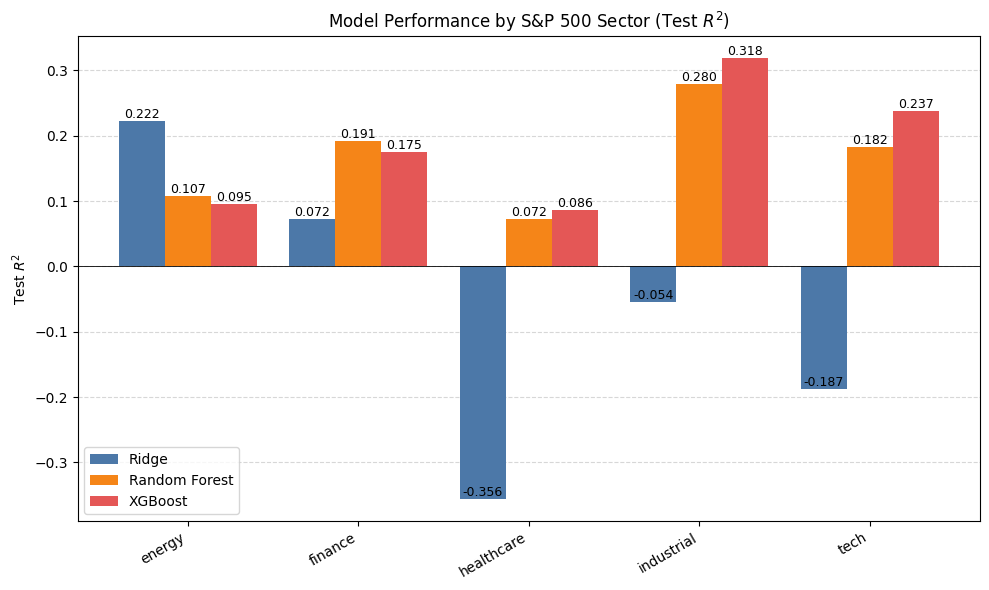

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Collect sectors (union, preserving order) and R² values
sectors = sorted(set(ridge_results) | set(rf_results))

ridge_r2 = [ridge_results[s]["test_metrics"]["r2"] if s in ridge_results else np.nan
            for s in sectors]
rf_r2    = [rf_results[s]["test_metrics"]["r2"]    if s in rf_results    else np.nan
            for s in sectors]
xgb_r2   = [xgb_reults[s]["test_metrics"]["r2"] if s in xgb_reults   else np.nan
            for s in sectors]

# Grouped bar chart
x = np.arange(len(sectors))
width = 0.27

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, ridge_r2, width, label="Ridge",         color="#4C78A8")
bars2 = ax.bar(x,         rf_r2,    width, label="Random Forest", color="#F58518")
bars3 = ax.bar(x + width, xgb_r2,   width, label="XGBoost",       color="#E45756")

# Value labels on top of bars
for bars in (bars1, bars2, bars3):
    for b in bars:
        h = b.get_height()
        if not np.isnan(h):
            ax.text(b.get_x() + b.get_width()/2, h,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=30, ha="right")
ax.set_ylabel("Test $R^2$")
ax.set_title("Model Performance by S&P 500 Sector (Test $R^2$)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

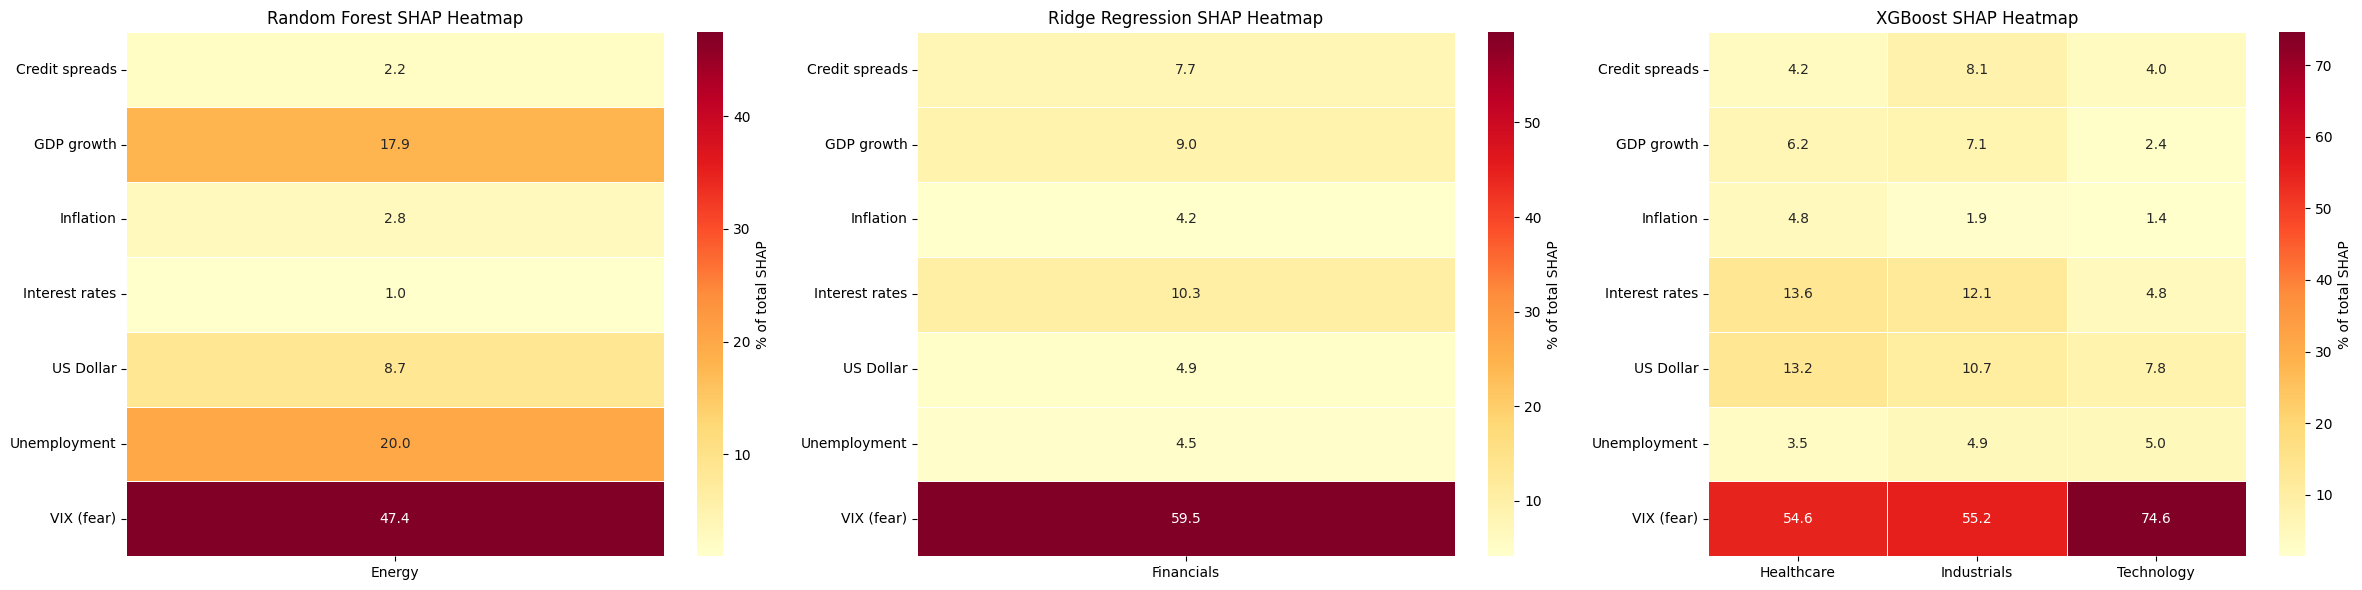

In [9]:
plt.figure(figsize=(12, 5))

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

plot_sector_heatmap(ridge_shap_data, sectors=['energy'], ax=axes[0])
axes[0].set_title("Random Forest SHAP Heatmap")

plot_sector_heatmap(rf_shap_data, sectors=['finance'], ax=axes[1])
axes[1].set_title("Ridge Regression SHAP Heatmap")

plot_sector_heatmap(xgb_shap_data, sectors=['healthcare','industrial','tech'], ax=axes[2])
axes[2].set_title("XGBoost SHAP Heatmap")


plt.tight_layout()
plt.show()

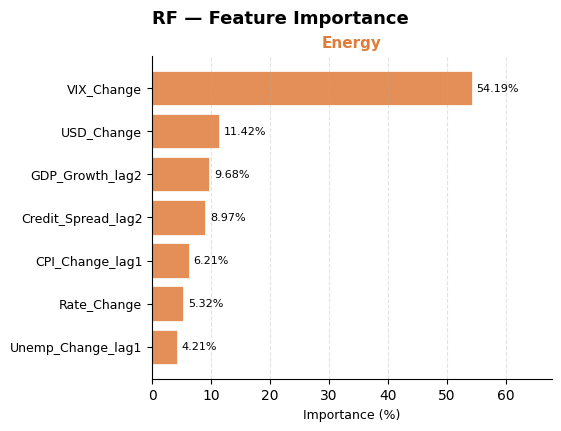

In [15]:
rf_fi = plot_feature_importance(rf_importance, model="rf", sectors=["energy"])

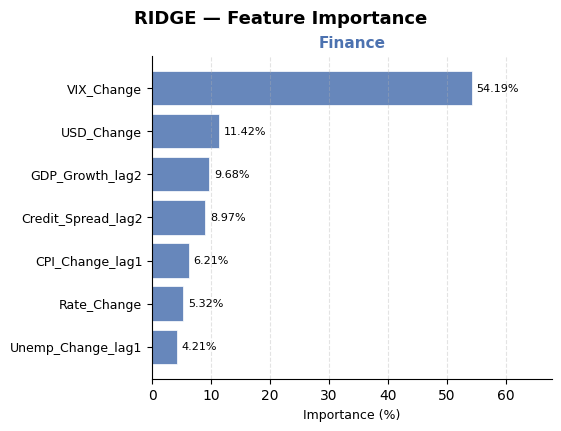

In [14]:
rr_fi = plot_feature_importance(ridge_importance, model="ridge", sectors=["finance"])

In [16]:
xgb_fi = plot_feature_importance(xgb_importance, model="xgb", sectors=["healthcare","industrial","tech"])

ValueError: Model 'xgb' not found. Available: []